In [2]:
# 문제1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# 문제2
delivery_df = pd.read_csv('../datasets/delivery_time.csv')

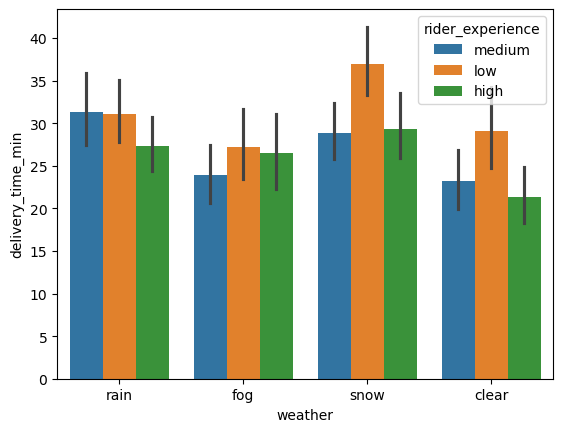

In [6]:
# 문제3
sns.barplot(
    delivery_df,
    x='weather',
    y='delivery_time_min',
    hue='rider_experience'
)

답3=3

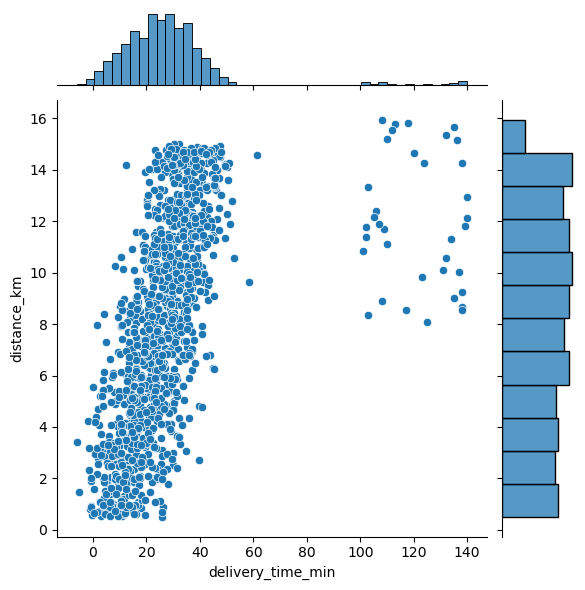

In [12]:
# 문제4
sns.jointplot(
    delivery_df,
    x='delivery_time_min',
    y='distance_km'
)

del_df = delivery_df.drop(delivery_df[delivery_df['delivery_time_min'] > 100].index, axis=0)

In [13]:
# 답5
del_df.drop(del_df[del_df['delivery_time_min'] < 0].index, axis=0, inplace=True)
del_df.reset_index(drop=True, inplace=True)

In [16]:
# 답6
del_df.drop(columns=['order_amount', 'num_items'], axis=1, inplace=True)

KeyError: "['order_amount', 'num_items'] not found in axis"

In [20]:
# 답7
cat_col=['rider_experience', 'weather', 'order_time']

encoding_df = pd.get_dummies(
    data=del_df,
    columns=cat_col,
    drop_first=True
)

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [30]:
# 답8
encoding_df['promotion_applied'] = le.fit_transform(y=encoding_df['promotion_applied'])

In [33]:
# 답9
from sklearn.model_selection import train_test_split

X = encoding_df.drop(columns='delivery_time_min', axis=1)
y = encoding_df['delivery_time_min']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [38]:
# 답10
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid)

/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [45]:
# 답11
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# 답12
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
tf.random.set_seed(42)

In [53]:
# 답13
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model.fit(
    X_train, 
    y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_valid, y_valid)
)

Epoch 1/50


/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 730.9137 - mean_absolute_error: 24.6082 - val_loss: 692.5005 - val_mean_absolute_error: 23.9746
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 700.5227 - mean_absolute_error: 24.1088 - val_loss: 642.3423 - val_mean_absolute_error: 23.0421
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 672.4056 - mean_absolute_error: 23.6335 - val_loss: 580.5745 - val_mean_absolute_error: 21.8372
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 644.9763 - mean_absolute_error: 23.1503 - val_loss: 505.4211 - val_mean_absolute_error: 20.2688
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 617.8406 - mean_absolute_error: 22.6510 - val_loss: 425.2985 - val_mean_absolute_error: 18.4492
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 590.6310 - mean_absolute_error: 22.1337 - val_loss: 342.5066 - val_mean_absolute_error: 16.3864
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 562.5646 - mean_absolute_error: 21.5826 - v

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [60]:
# 답14
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_check_point = ModelCheckpoint(
    monitor='val_loss',
    save_best_only=True,
    filepath='best_model.h5',
    verbose=1
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping, model_check_point]
)



Epoch 1/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 30.1694 - mean_absolute_error: 4.5782

/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mean_absolute_error
  current = self.get_monitor_value(logs)
/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29.1980 - mean_absolute_error: 4.2863 
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30.0867 - mean_absolute_error: 4.5758

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.0289 - mean_absolute_error: 4.2730
Epoch 3/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 29.9320 - mean_absolute_error: 4.5630

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28.8842 - mean_absolute_error: 4.2590
Epoch 4/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29.7997 - mean_absolute_error: 4.5502

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.5417 - mean_absolute_error: 3.7745
Epoch 47/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24.0235 - mean_absolute_error: 3.9850

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.4057 - mean_absolute_error: 3.7681
Epoch 48/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.8005 - mean_absolute_error: 3.9511

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.3201 - mean_absolute_error: 3.7531
Epoch 49/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.8747 - mean_absolute_error: 3.9806

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.2355 - mean_absolute_error: 3.7586
Epoch 50/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.8904 - mean_absolute_error: 3.9481

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.2296 - mean_absolute_error: 3.7504
